# Listing Remarks Exploration

This notebook explores patterns in the real estate listing remarks, including text length, common terms, and n-grams.

In [27]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Ensure project root is on sys.path so `scripts` can be imported
# Works whether kernel cwd is project root or notebooks/
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "scripts").is_dir() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline

remarks_df = pd.read_csv("../data/processed/listing_sample.csv")
remarks_df["length"] = remarks_df["remarks"].astype(str).str.len()

remarks_df[["length"]].describe()

,length
count,1000.000000
mean,1197.498000
std,541.749997
min,67.000000
25%,825.500000
50%,1143.000000
75%,1465.000000
max,3678.000000


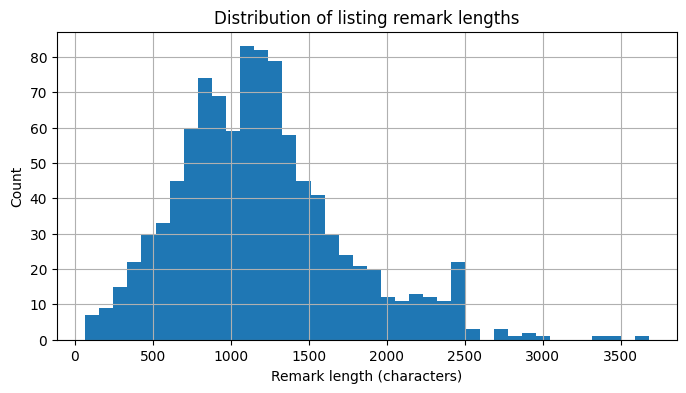

In [28]:
# Histogram of remark lengths
plt.figure(figsize=(8, 4))
remarks_df["length"].hist(bins=40)
plt.xlabel("Remark length (characters)")
plt.ylabel("Count")
plt.title("Distribution of listing remark lengths")
plt.show()

In [29]:
# Simple token frequency exploration
all_text = " ".join(remarks_df["remarks"].astype(str).str.lower())
words = all_text.split()
word_counts = Counter(words)

for word, count in list(word_counts.most_common(30)):
    print(f"{word}: {count}")

and: 8690
the: 7439
a: 7352
with: 3593
to: 3058
of: 2603
for: 2488
this: 2290
in: 2184
home: 1869
is: 1724
an: 1319
living: 1244
or: 1113
offers: 868
room: 824
kitchen: 755
private: 731
on: 673
features: 666
that: 636
from: 616
spacious: 605
located: 601
your: 599
perfect: 582
new: 581
large: 515
space: 491
by: 475


In [30]:
from scripts.text_cleaning import TextCleaner

cleaner = TextCleaner()

before_profile = cleaner.profile_column(remarks_df, "remarks")
remarks_df["remarks_clean"] = remarks_df["remarks"].apply(cleaner.clean_text)
after_profile = cleaner.profile_column(remarks_df, "remarks_clean")

before_profile, after_profile

({'null_rate': 0.0,
  'avg_length': 1197.498,
  'common_terms': [('and a', 1067),
   ('in the', 744),
   ('with a', 676),
   ('of the', 574),
   ('to the', 568),
   ('this home', 469),
   ('perfect for', 466),
   ('the home', 441),
   ('square feet', 405),
   ('walk in', 404),
   ('is a', 384),
   ('ideal for', 350),
   ('a private', 337),
   ('access to', 311),
   ('primary suite', 303),
   ('living room', 293),
   ('to a', 276),
   ('welcome to', 276),
   ('car garage', 267),
   ('and the', 266)],
  'price_mentions': 65,
  'has_html': 0,
  'common_abbreviations': [('ac', 980),
   ('ba', 923),
   ('dr', 906),
   ('ss', 867),
   ('fr', 787),
   ('kit', 754),
   ('br', 552),
   ('gar', 537),
   ('att', 212),
   ('gran', 197),
   ('det', 156),
   ('hoa', 128),
   ('hw', 112),
   ('sq ft', 96),
   ('hvac', 70),
   ('sf', 60),
   ('sqft', 34),
   ('w/', 28),
   ('a/c', 27),
   ('lr', 25)]},
 {'null_rate': 0.0,
  'avg_length': 1203.117,
  'common_terms': [('and a', 1067),
   ('in the', 744)

In [31]:
# Before/after examples
remarks_df[["remarks", "remarks_clean"]].head(10)
remarks_df[["remarks", "remarks_clean"]].tail(10)

,remarks,remarks_clean
990,Discover this beautifully maintained residence...,Discover this beautifully maintained residence...
991,"A smart alternative to traditional housing, th...","A smart alternative to traditional housing, th..."
992,"Stunning Bay, City, and Sunset Views!!!!! Fro...","Stunning Bay, City, and Sunset Views! From Thi..."
993,"Welcome to this beautifully updated 4-bedroom,...","Welcome to this beautifully updated 4-bedroom,..."
994,Experience luxury high-rise living at its fine...,Experience luxury high-rise living at its fine...
995,"Nice 3 bedroom, 2 bath 1100 Sq ft home with fi...","Nice 3 bedroom, 2 bath 1100 square feet home w..."
996,Located in the highly coveted Lake Hollywood E...,Located in the highly coveted Lake Hollywood E...
997,Discover your dream mountain retreat at 7575 U...,Discover your dream mountain retreat at 7575 U...
998,NEW LOWER PRICE! Check out this beautiful sing...,NEW LOWER PRICE! Check out this beautiful sing...
999,Welcome to your dream home in Palm Desert! Thi...,Welcome to your dream home in Palm Desert! Thi...


In [32]:
## Entity Extraction (Week 3 Deliverables)
'''
This section explores the **EntityExtractor** (regex + Week 1 taxonomy), the **labeled dataset** (200–300 remarks with entity spans), and **evaluation** (precision/recall/F1 + error analysis).
'''

'\nThis section explores the **EntityExtractor** (regex + Week 1 taxonomy), the **labeled dataset** (200–300 remarks with entity spans), and **evaluation** (precision/recall/F1 + error analysis).\n'

### 1. EntityExtractor — regex patterns + amenity taxonomy

The `EntityExtractor` class extracts **bedrooms**, **bathrooms**, **price**, **square footage**, and **amenities** (using the Week 1 taxonomy). 

In [33]:
import importlib
import scripts.entity_extractor
importlib.reload(scripts.entity_extractor)
from scripts.entity_extractor import EntityExtractor

extractor = EntityExtractor()

# Use cleaned remarks if available for consistency with Week 2
sample_texts = remarks_df["remarks_clean"].fillna(remarks_df["remarks"]).astype(str).head(5).tolist()

for i, text in enumerate(sample_texts):
    result = extractor.extract_all(text)
    print(f"--- Remark {i+1} (first 120 chars) ---")
    print(text[:120] + "..." if len(text) > 120 else text)
    print("Extracted:", result)
    print()

--- Remark 1 (first 120 chars) ---
Successful vacation rental just minutes from Snow Summit, Bear Mountain shuttles and parking, hiking trails, and the zoo...
Extracted: {'bedrooms': None, 'bathrooms': None, 'price': None, 'sqft': [], 'amenities': ['living space', 'spacious', 'space']}

--- Remark 2 (first 120 chars) ---
This must-see home, less than five years old, is nestled in a gated community. It boasts a spacious four-bedroom, two-an...
Extracted: {'bedrooms': None, 'bathrooms': None, 'price': None, 'sqft': [], 'amenities': ['garage', 'spacious', 'space']}

--- Remark 3 (first 120 chars) ---
New construction with an ADU in the heart of University Heights, this residence blends modern amenities, stunning views,...
Extracted: {'bedrooms': None, 'bathrooms': None, 'price': None, 'sqft': [9], 'amenities': ['garage', 'laundry room', 'space']}

--- Remark 4 (first 120 chars) ---
This charming 2-bedroom, 1-bath home is where classic character meets modern comfort. Beautiful hardwood flo

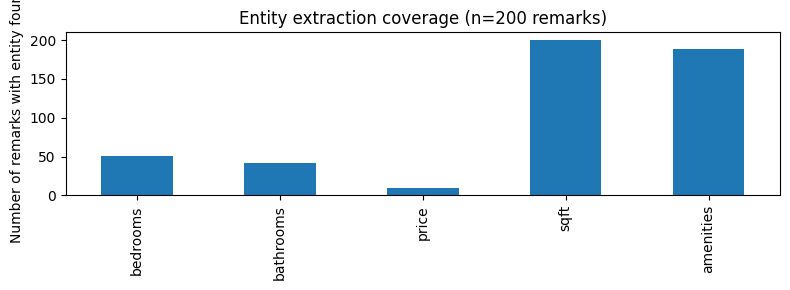

Counts: {'bedrooms': 51, 'bathrooms': 42, 'price': 10, 'sqft': 200, 'amenities': 188}


In [34]:
# Coverage of entity types across first 200 remarks
texts = remarks_df["remarks_clean"].fillna(remarks_df["remarks"]).astype(str).head(200).tolist()
counts = {"bedrooms": 0, "bathrooms": 0, "price": 0, "sqft": 0, "amenities": 0}
for t in texts:
    out = extractor.extract_all(t)
    if out.get("bedrooms") is not None:
        counts["bedrooms"] += 1
    if out.get("bathrooms") is not None:
        counts["bathrooms"] += 1
    if out.get("price") is not None:
        counts["price"] += 1
    if out.get("sqft") is not None:
        counts["sqft"] += 1
    if out.get("amenities"):
        counts["amenities"] += 1

pd.Series(counts).plot(kind="bar", figsize=(8, 3), title="Entity extraction coverage (n=200 remarks)")
plt.ylabel("Number of remarks with entity found")
plt.tight_layout()
plt.show()
print("Counts:", counts)

### 2. Labeled dataset — 200–300 remarks with entity spans

The labeled dataset is stored as **JSONL** (`data/processed/remarks_labeled.jsonl`). Each line has `id`, `text`, and `entities` (list of spans with `label`, `start`, `end`, `value`). Generated by `scripts/build_labeled_dataset.py` (weak labels from the extractor; can be refined manually).

In [35]:
import json

labeled_path = PROJECT_ROOT / "data" / "processed" / "remarks_labeled.jsonl"
labeled_records = []
if labeled_path.exists():
    with open(labeled_path) as f:
        for line in f:
            line = line.strip()
            if line:
                labeled_records.append(json.loads(line))

print(f"Labeled dataset: {len(labeled_records)} remarks")
if labeled_records:
    # Entity type distribution
    type_counts = {}
    for rec in labeled_records:
        for ent in rec.get("entities", []):
            label = ent.get("label", "?")
            type_counts[label] = type_counts.get(label, 0) + 1
    print("Entity spans by type:", dict(sorted(type_counts.items())))
    # Sample record
    ex = labeled_records[0]
    print("\nSample record (first 200 chars of text + entities):")
    print("Text:", ex["text"][:200] + "..." if len(ex["text"]) > 200 else ex["text"])
    print("Entities:", ex["entities"][:8])
else:
    print("Run scripts/build_labeled_dataset.py to generate the file.")

Labeled dataset: 250 remarks
Entity spans by type: {'AMENITY': 727, 'BATHROOMS': 74, 'BEDROOMS': 72, 'PRICE': 65, 'SQFT': 23}

Sample record (first 200 chars of text + entities):
Text: Stunning, luxury duplex located close to world famous beaches, shopping and fine dining. All situated in the quaint setting of downtown San Clemente. Built in 2005 all upgraded details throughout.  Ve...
Entities: [{'label': 'BEDROOMS', 'start': 244, 'end': 249, 'value': 2}, {'label': 'BATHROOMS', 'start': 258, 'end': 264, 'value': 2.0}, {'label': 'AMENITY', 'start': 287, 'end': 293, 'value': 'garage'}]


### 3. Evaluation — precision, recall, F1 (target 85%+ F1)

We run the evaluation script logic on the labeled dataset. Metrics are computed per entity type (value-based match); macro-average F1 is the main target. An **error analysis** section at the end of the script highlights top failure patterns (FN/FP examples).

In [36]:
# Run evaluation using the script's logic (no subprocess)
# Reload so notebook picks up latest changes to scripts without restarting kernel
import importlib
import scripts.entity_extractor
import scripts.evaluate_entity_extractor
importlib.reload(scripts.entity_extractor)
importlib.reload(scripts.evaluate_entity_extractor)
from scripts.entity_extractor import EntityExtractor
from scripts.evaluate_entity_extractor import (
    load_labeled_data,
    prediction_from_extractor,
    entities_by_type,
    compute_prf,
    DEFAULT_LABELS_PATH,
)

eval_path = PROJECT_ROOT / "data" / "processed" / "remarks_labeled.jsonl"
if not eval_path.exists():
    eval_path = PROJECT_ROOT / DEFAULT_LABELS_PATH
if not eval_path.exists():
    eval_path = DEFAULT_LABELS_PATH

records = load_labeled_data(eval_path) if eval_path.exists() else []
extractor = EntityExtractor()

labels = ["BEDROOMS", "BATHROOMS", "PRICE", "SQFT", "AMENITY"]
agg_gold = {l: [] for l in labels}
agg_pred = {l: [] for l in labels}

for rec in records:
    text = rec.get("text", "")
    gold_by_type = entities_by_type(rec)
    pred_by_type = prediction_from_extractor(text, extractor)
    for label in labels:
        agg_gold[label].extend(gold_by_type.get(label, []))
        agg_pred[label].extend(pred_by_type.get(label, []))

if not records:
    print("No labeled data found. Run: python scripts/build_labeled_dataset.py")
else:
    print(f"Evaluated on {len(records)} labeled remarks\n")
    print(f"{'Label':<12} {'P':>8} {'R':>8} {'F1':>8}")
    print("-" * 40)
    macro_f1 = 0
    for label in labels:
        _, _, _, p, r, f1 = compute_prf(agg_gold[label], agg_pred[label])
        macro_f1 += f1
        print(f"{label:<12} {p:>8.3f} {r:>8.3f} {f1:>8.3f}")
    print("-" * 40)
    print(f"{'Macro':<12} {'':>8} {'':>8} {macro_f1/len(labels):>8.3f}")
    print("\nTarget: 85%+ F1 on test set. Refine labels and add regex patterns to improve.")

Evaluated on 250 labeled remarks

Label               P        R       F1
----------------------------------------
BEDROOMS        0.960    1.000    0.980
BATHROOMS       0.974    1.000    0.987
PRICE           0.819    0.908    0.861
SQFT            0.351    0.870    0.500
AMENITY         1.000    0.842    0.914
----------------------------------------
Macro                             0.848

Target: 85%+ F1 on test set. Refine labels and add regex patterns to improve.


### 4. Error analysis — top failure patterns

Inspecting a few **false negative** and **false positive** examples helps identify missing regex patterns or taxonomy terms. Run the full evaluation script from the terminal for the full report:

```bash
python scripts/evaluate_entity_extractor.py --labels-path data/processed/remarks_labeled.jsonl
```

Below we show a quick in-notebook sample of disagreements (predicted vs gold) for one entity type.

In [37]:
# Quick error-analysis sample: BEDROOMS where gold and pred differ
from scripts.evaluate_entity_extractor import normalize_value
from collections import Counter

sample_label = "BEDROOMS"
fn_fp_examples = []
for rec in records:
    text = rec.get("text", "")
    gold_by_type = entities_by_type(rec)
    pred_by_type = prediction_from_extractor(text, extractor)
    g = gold_by_type.get(sample_label, [])
    p = pred_by_type.get(sample_label, [])
    gold_vals = Counter(normalize_value(e.get("value")) for e in g)
    pred_vals = Counter(normalize_value(e.get("value")) for e in p)
    fn_vals = gold_vals - pred_vals
    fp_vals = pred_vals - gold_vals
    if fn_vals or fp_vals:
        fn_fp_examples.append({
            "text_preview": text[:150] + "..." if len(text) > 150 else text,
            "gold": list(gold_vals.elements()),
            "pred": list(pred_vals.elements()),
            "fn": dict(fn_vals),
            "fp": dict(fp_vals),
        })
        if len(fn_fp_examples) >= 3:
            break

print(f"Sample disagreements for {sample_label} (up to 3):")
if not fn_fp_examples:
    print("No disagreements found in this sample (or no labeled data).")
for i, ex in enumerate(fn_fp_examples, 1):
    print(f"\n--- Example {i} ---")
    print("Text:", ex["text_preview"])
    print("Gold:", ex["gold"], "| Pred:", ex["pred"])
    if ex["fn"]:
        print("False negatives (missed):", ex["fn"])
    if ex["fp"]:
        print("False positives (extra):", ex["fp"])

Sample disagreements for BEDROOMS (up to 3):

--- Example 1 ---
Text: Located on a cul-de-sac in the highly desirable North Pomona area, bordering La Verne. 3 BD, 1 BA, 2 Car Detached Garage, driveway parking, enclosed p...
Gold: [] | Pred: [3]
False positives (extra): {3: 1}

--- Example 2 ---
Text: Tastefully updated Hilmar home. This 3br 2 Ba home is centrally located in Hilmar and close to shopping and amenities. Inside you will enjoy an open c...
Gold: [] | Pred: [3]
False positives (extra): {3: 1}

--- Example 3 ---
Text: Welcome to this exceptional newly constructed home offering approximately 3278 sq ft of thoughtfully designed living space on an expansive 108,900 sq ...
Gold: [] | Pred: [5]
False positives (extra): {5: 1}


In [38]:
from scripts.query_parser import QueryParser
from scripts.schema_validator import SchemaValidator

parser = QueryParser()
validator = SchemaValidator()  # auto-loads valid cities from listing_sample if available

example_queries = [
    "3 bed under 700k in Irvine",
    "4 bed 3 bath between 800k and 1.2m in Irvine with pool",
    "studio under 500k in San Diego no pool",
    "3-4 bed at least 2 bath over 900k near Los Angeles with garage",
]

for q in example_queries:
    parsed = parser.parse_to_sql(q)
    valid = validator.validate_filters(parsed.filters)
    print("\n=== Query ===")
    print(q)
    print("Filters:", parsed.filters)
    print("WHERE SQL:", parsed.where_sql or "<no filters>")
    print("Params:", parsed.params)
    print("Validation ok:", valid.ok)
    if not valid.ok:
        print("  Errors:", valid.errors)


=== Query ===
3 bed under 700k in Irvine
Filters: {'price_max': 700000, 'bedrooms_min': 3, 'bedrooms_max': 3, 'city': 'Irvine'}
WHERE SQL: L_SystemPrice <= %s AND L_Keyword2 >= %s AND L_Keyword2 <= %s AND L_City = %s
Params: [700000, 3, 3, 'Irvine']
Validation ok: True

=== Query ===
4 bed 3 bath between 800k and 1.2m in Irvine with pool
Filters: {'price_min': 800000, 'price_max': 1200000, 'bedrooms_min': 4, 'bedrooms_max': 4, 'bathrooms_min': 3.0, 'bathrooms_max': 3.0, 'city': 'Irvine', 'amenities_in': ['pool']}
WHERE SQL: L_SystemPrice >= %s AND L_SystemPrice <= %s AND L_Keyword2 >= %s AND L_Keyword2 <= %s AND LM_Dec_3 >= %s AND LM_Dec_3 <= %s AND L_City = %s AND LOWER(L_Remarks) LIKE %s
Params: [800000, 1200000, 4, 4, 3.0, 3.0, 'Irvine', '%pool%']
Validation ok: True

=== Query ===
studio under 500k in San Diego no pool
Filters: {'price_max': 500000, 'bedrooms_max': 0, 'city': 'San Diego', 'amenities_out': ['pool']}
WHERE SQL: L_SystemPrice <= %s AND L_Keyword2 <= %s AND L_City = %

In [39]:
import random
from collections import Counter

from scripts.query_parser import QueryParser
from scripts.schema_validator import SchemaValidator

# Re‑use the listing sample to get realistic city names
cities = (
    remarks_df.get("L_City")
    if "L_City" in remarks_df.columns
    else remarks_df.get("city")
)
if cities is not None:
    city_pool = sorted({str(c).strip() for c in cities.dropna() if str(c).strip()})
else:
    city_pool = ["Irvine", "San Diego", "Los Angeles", "Palm Desert"]

parser = QueryParser()
validator = SchemaValidator(valid_cities=city_pool)

random.seed(42)

TEMPLATES = [
    "{beds} bed under {price} in {city}",
    "between {min_price} and {max_price} with {amenity} in {city}",
    "{beds_min}-{beds_max} bed at least {baths} bath over {price} near {city}",
    "studio under {price} in {city} no {amenity}",
    "at least {beds} bedrooms and {baths} baths below {price} in {city}",
]

AMENITIES = ["pool", "garage", "fireplace", "hardwood", "basement", "waterfront"]

N = 50
results = []

for _ in range(N):
    city = random.choice(city_pool) if city_pool else "Irvine"
    amenity = random.choice(AMENITIES)
    beds = random.randint(1, 5)
    beds_min = random.randint(2, 4)
    beds_max = beds_min + random.randint(0, 2)
    baths = random.choice([1, 1.5, 2, 2.5, 3])
    price = random.choice(["450k", "600k", "750k", "900k", "1.2m"])
    min_price = random.choice(["400k", "500k", "700k"])
    max_price = random.choice(["800k", "900k", "1.5m"])

    tpl = random.choice(TEMPLATES)
    q = tpl.format(
        beds=beds,
        beds_min=beds_min,
        beds_max=beds_max,
        baths=baths,
        price=price,
        min_price=min_price,
        max_price=max_price,
        amenity=amenity,
        city=city,
    )

    parsed = parser.parse_to_sql(q)
    validation = validator.validate_filters(parsed.filters)
    results.append({
        "query": q,
        "filters": parsed.filters,
        "where_sql": parsed.where_sql,
        "params": parsed.params,
        "valid": validation.ok,
        "errors": validation.errors,
    })

# Aggregate simple stats
field_counts = Counter()
valid_count = 0
for r in results:
    f = r["filters"]
    for key in ["price_min", "price_max", "bedrooms_min", "bedrooms_max", "bathrooms_min", "city", "amenities_in", "amenities_out"]:
        if key in f and f[key]:
            field_counts[key] += 1
    if r["valid"]:
        valid_count += 1

print(f"Generated {N} synthetic queries")
print(f"Validation ok for {valid_count}/{N} ({valid_count / N:.1%})")
print("\nField presence across queries:")
for k, v in sorted(field_counts.items()):
    print(f"  {k:15s}: {v}/{N}")

print("\nSample parses (first 5):")
for r in results[:5]:
    print("\n=== Query ===")
    print(r["query"])
    print("Filters:", r["filters"])
    print("WHERE SQL:", r["where_sql"] or "<no filters>")
    print("Params:", r["params"])
    print("Valid:", r["valid"])
    if not r["valid"]:
        print("  Errors:", r["errors"])

Generated 50 synthetic queries
Validation ok for 49/50 (98.0%)

Field presence across queries:
  amenities_in   : 13/50
  amenities_out  : 9/50
  bathrooms_min  : 16/50
  bedrooms_max   : 23/50
  bedrooms_min   : 28/50
  city           : 49/50
  price_max      : 39/50
  price_min      : 24/50

Sample parses (first 5):

=== Query ===
1 bed under 600k in Vallejo
Filters: {'price_max': 600000, 'bedrooms_min': 1, 'bedrooms_max': 1, 'city': 'Vallejo'}
WHERE SQL: L_SystemPrice <= %s AND L_Keyword2 >= %s AND L_Keyword2 <= %s AND L_City = %s
Params: [600000, 1, 1, 'Vallejo']
Valid: True

=== Query ===
between 400k and 800k with waterfront in Winchester
Filters: {'price_min': 400000, 'price_max': 800000, 'city': 'Winchester', 'amenities_in': ['waterfront']}
WHERE SQL: L_SystemPrice >= %s AND L_SystemPrice <= %s AND L_City = %s AND LOWER(L_Remarks) LIKE %s
Params: [400000, 800000, 'Winchester', '%waterfront%']
Valid: True

=== Query ===
studio under 1.2m in Hermosa Beach no basement
Filters: {'p